# Análisis exploratorio: Online Retail II

Exploración del dataset de ventas retail online (transacciones, productos, clientes y países).

**Contenido:**
- Carga y primera inspección
- Calidad de datos (nulos, duplicados, tipos)
- Estadísticas descriptivas
- Visualizaciones (distribuciones, series temporales, categorías)
- Conclusiones del EDA

**Dudas**  
¿cómo calcula los revenues?
tendría sentido quitar cuando tenemos identificada una compra?
varios modelos segun comportamiento del cliente?
entender bien como hace la construccion del data set agregado
 


In [1]:
#pip install openpyxl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from pandas.tseries.offsets import DateOffset

pd.set_option('display.max_columns', 20)
plt.style.use('ggplot')
sns.set_palette('husl')

## 1. Carga de datos

In [3]:
# Ruta al dataset (ajusta si es necesario)
df = pd.read_parquet("data/data_clean.parquet")
df.shape

(797815, 17)

## 2. Primera inspección

In [4]:
df.head(10)

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,is_return,quantity_pos,quantity_neg,total_price,year,month,day,day_of_week,hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,False,12,0,83.4,2009,12,1,1,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,12,0,81.0,2009,12,1,1,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,12,0,81.0,2009,12,1,1,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,False,48,0,100.8,2009,12,1,1,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False,24,0,30.0,2009,12,1,1,7
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom,False,24,0,39.6,2009,12,1,1,7
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False,24,0,30.0,2009,12,1,1,7
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom,False,10,0,59.5,2009,12,1,1,7
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085,United Kingdom,False,12,0,30.6,2009,12,1,1,7
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085,United Kingdom,False,12,0,45.0,2009,12,1,1,7


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797815 entries, 0 to 797814
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice       797815 non-null  string        
 1   stock_code    797815 non-null  string        
 2   description   797815 non-null  string        
 3   quantity      797815 non-null  int64         
 4   invoice_date  797815 non-null  datetime64[ns]
 5   price         797815 non-null  float64       
 6   customer_id   797815 non-null  Int64         
 7   country       797815 non-null  category      
 8   is_return     797815 non-null  bool          
 9   quantity_pos  797815 non-null  int64         
 10  quantity_neg  797815 non-null  int64         
 11  total_price   797815 non-null  float64       
 12  year          797815 non-null  int32         
 13  month         797815 non-null  int32         
 14  day           797815 non-null  int32         
 15  day_of_week   797

In [6]:
df.dtypes

invoice         string[python]
stock_code      string[python]
description     string[python]
quantity                 int64
invoice_date    datetime64[ns]
price                  float64
customer_id              Int64
country               category
is_return                 bool
quantity_pos             int64
quantity_neg             int64
total_price            float64
year                     int32
month                    int32
day                      int32
day_of_week              int32
hour                     int32
dtype: object

## 3. Calidad de datos

In [7]:
## chequear nulos y duplicados

## 4. Estadísticas descriptivas
df.describe()

## 5. Visualizaciones

In [8]:
### importante gestionarla visualizacion cuando hay outliers 

In [9]:
max_date = df["invoice_date"].max()
max_date

Timestamp('2011-12-09 12:50:00')

In [10]:
cutoff_date = max_date - DateOffset(months=3)
cutoff_date

Timestamp('2011-09-09 12:50:00')

In [11]:
df_past = df[df["invoice_date"] <= cutoff_date].copy()
df_future = df[df["invoice_date"] > cutoff_date].copy()

In [12]:
df_past.tail(3)

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,is_return,quantity_pos,quantity_neg,total_price,year,month,day,day_of_week,hour
635123,566178,22670,FRENCH WC SIGN BLUE METAL,24,2011-09-09 12:41:00,1.25,16353,United Kingdom,False,24,0,30.0,2011,9,9,4,12
635124,566178,21218,RED SPOTTY BISCUIT TIN,12,2011-09-09 12:41:00,3.75,16353,United Kingdom,False,12,0,45.0,2011,9,9,4,12
635125,566178,23574,PACKING CHARGE,1,2011-09-09 12:41:00,7.50,16353,United Kingdom,False,1,0,7.5,2011,9,9,4,12


In [13]:
df_future.head(3)

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,is_return,quantity_pos,quantity_neg,total_price,year,month,day,day_of_week,hour
635126,C566180,21314,SMALL GLASS HEART TRINKET POT,-1,2011-09-09 12:52:00,2.10,16173,United Kingdom,True,0,-1,-2.10,2011,9,9,4,12
635127,C566180,22800,ANTIQUE TALL SWIRLGLASS TRINKET POT,-1,2011-09-09 12:52:00,3.75,16173,United Kingdom,True,0,-1,-3.75,2011,9,9,4,12
635128,C566180,22798,ANTIQUE GLASS DRESSING TABLE POT,-2,2011-09-09 12:52:00,2.95,16173,United Kingdom,True,0,-2,-5.90,2011,9,9,4,12


## 6. Agrupación por cliente (Customer ID)

Por cada cliente: **suma de tickets en el año** (facturación total), **número de compras** (facturas distintas) y **ticket medio** por compra.

In [14]:
features = df_past.groupby("customer_id").agg(
    frequency=("invoice", "nunique"),
    monetary=("total_price", "sum"),
    avg_ticket=("total_price", "mean"),
    total_quantity=("quantity_pos", "sum"),
    n_products=("stock_code", "nunique"),
    n_returns=("is_return", "sum")
)

In [15]:
reference_date = df_past["invoice_date"].max()

recency = df_past.groupby("customer_id")["invoice_date"].max()
recency = (reference_date - recency).dt.days

features["recency"] = recency

In [16]:
features["return_rate"] = features["n_returns"] / features["frequency"]
features["return_rate"] = features["return_rate"].fillna(0)

In [17]:
target = df_future.groupby("customer_id")["invoice"].nunique()
target = (target > 0).astype(int)
target.name = "target"

In [18]:
df_model = features.merge(target, on="customer_id", how="left")
df_model["target"] = df_model["target"].fillna(0).astype(int)

In [19]:
display(df_model.head())
display(df_model.shape)
display(df_model["target"].value_counts())
df_model.isna().sum()

,frequency,monetary,avg_ticket,total_quantity,n_products,n_returns,recency,return_rate,target
customer_id,,,,,,,,,
12346,17,-51.74,-1.100851,74285,30,13,234,0.764706,0
12347,6,3402.39,20.746280,2099,107,0,38,0.000000,1
12348,4,1709.40,35.612500,2497,25,0,157,0.000000,1
12349,4,2646.99,24.738224,993,92,5,316,1.250000,1
12350,1,334.40,19.670588,197,17,0,218,0.000000,0


(5342, 9)

target
0    3018
1    2324
Name: count, dtype: int64

frequency         0
monetary          0
avg_ticket        0
total_quantity    0
n_products        0
n_returns         0
recency           0
return_rate       0
target            0
dtype: int64

## 7. Modelo: probabilidad de recompra

Modelo supervisado para estimar la probabilidad de que un cliente **vuelva a comprar** después de una fecha de corte.

Estrategia:
- Definimos una **fecha de corte** (`cutoff_date`).
- Con los datos **antes** de esa fecha construimos variables por cliente (RFM simplificado: recencia, frecuencia, gasto total, ticket medio, país, etc.).
- Con los datos **después** de la fecha etiquetamos si el cliente **recompró (1)** o **no recompró (0)**.
- Entrenamos una **regresión logística** para predecir esa probabilidad de recompra.

### (Opcional) Búsqueda de hiperparámetros
randomsearch, gridsearch, optuna, 


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

In [24]:
X = df_model.drop(columns=["target"])
y = df_model["target"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.76      0.82      0.79       604
           1       0.74      0.66      0.70       465

    accuracy                           0.75      1069
   macro avg       0.75      0.74      0.74      1069
weighted avg       0.75      0.75      0.75      1069

ROC-AUC: 0.8084526098412019


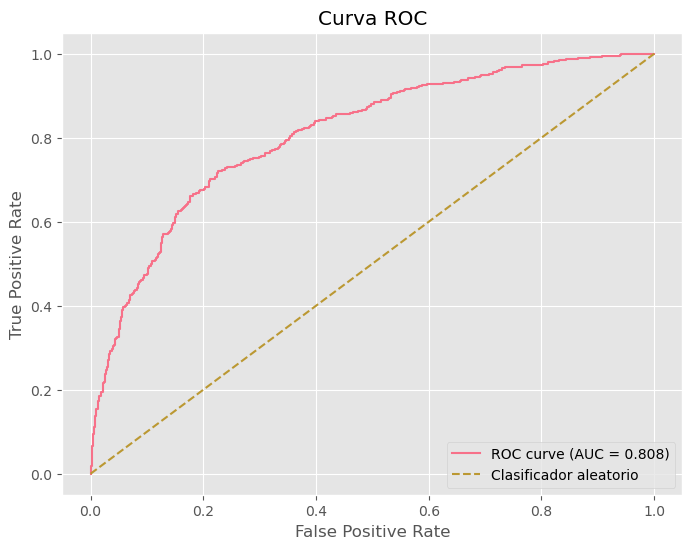

In [29]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilidades de la clase positiva
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Gráfico
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.show()

In [30]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [31]:
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [35]:
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train, y_train)

y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

[LightGBM] [Info] Number of positive: 1859, number of negative: 2414
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001263 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1614
[LightGBM] [Info] Number of data points in the train set: 4273, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.435057 -> initscore=-0.261246
[LightGBM] [Info] Start training from score -0.261246


In [32]:
print("Logistic:", roc_auc_score(y_test, y_prob))
print("RF:", roc_auc_score(y_test, y_prob_rf))
print("XGB:", roc_auc_score(y_test, y_prob_xgb))

Logistic: 0.8084526098412019
RF: 0.7814783165990172
XGB: 0.771772413302001


In [36]:
# Logistic
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob)
auc_log = auc(fpr_log, tpr_log)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

#LightGBM
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm)
auc_lgbm = auc(fpr_lgbm, tpr_lgbm)

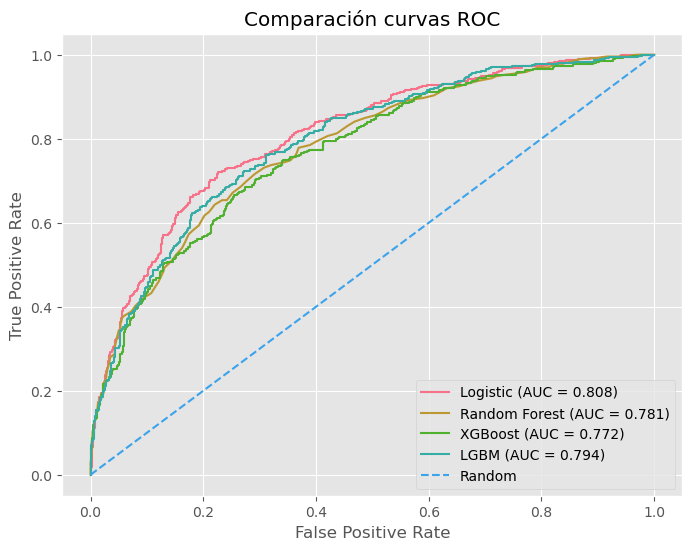

Logistic AUC: 0.808
RF AUC: 0.781
XGB AUC: 0.772
LGBM AUC: 0.794


In [37]:
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")
plt.plot(fpr_lgbm, tpr_lgbm, label=f"LGBM (AUC = {auc_lgbm:.3f})")

# línea base
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparación curvas ROC")
plt.legend(loc="lower right")

plt.show()
print(f"Logistic AUC: {auc_log:.3f}")
print(f"RF AUC: {auc_rf:.3f}")
print(f"XGB AUC: {auc_xgb:.3f}")
print(f"LGBM AUC: {auc_lgbm:.3f}")

# Optimización de hiperparamtros

In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid_log = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],  # l1 solo con liblinear
    "solver": ["lbfgs"]
}

log = LogisticRegression(max_iter=1000, random_state=42)

grid_log = GridSearchCV(
    log,
    param_grid_log,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_log.fit(X_train_scaled, y_train)

best_log = grid_log.best_estimator_

print(grid_log.best_params_)
print(grid_log.best_score_)

{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
0.7947486479242858


In [39]:
from lightgbm import LGBMClassifier

param_grid_lgbm = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [-1, 5, 10],
    "num_leaves": [31, 50]
}

lgbm = LGBMClassifier(random_state=42)

grid_lgbm = GridSearchCV(
    lgbm,
    param_grid_lgbm,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

grid_lgbm.fit(X_train, y_train)

best_lgbm = grid_lgbm.best_estimator_

print(grid_lgbm.best_params_)
print(grid_lgbm.best_score_)

[LightGBM] [Info] Number of positive: 1859, number of negative: 2414
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000296 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1614
[LightGBM] [Info] Number of data points in the train set: 4273, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.435057 -> initscore=-0.261246
[LightGBM] [Info] Start training from score -0.261246
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [40]:
# Logistic optimizada
y_prob_log_opt = best_log.predict_proba(X_test_scaled)[:, 1]

# LGBM optimizado
y_prob_lgbm_opt = best_lgbm.predict_proba(X_test)[:, 1]

print("Logistic OPT:", roc_auc_score(y_test, y_prob_log_opt))
print("LGBM OPT:", roc_auc_score(y_test, y_prob_lgbm_opt))

Logistic OPT: 0.8084953357544685
LGBM OPT: 0.8046108381399987


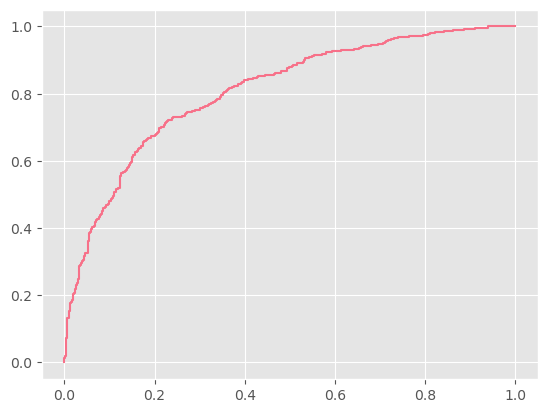

In [41]:
fpr_log_opt, tpr_log_opt, _ = roc_curve(y_test, y_prob_log_opt)
auc_log_opt = auc(fpr_log_opt, tpr_log_opt)

plt.plot(fpr_log_opt, tpr_log_opt, label=f"Logistic OPT (AUC = {auc_log_opt:.3f})")

In [42]:
X_all = df_model.drop(columns=["target"])
X_all_scaled = scaler.transform(X_all)
df_model["prob_recompra"] = best_log.predict_proba(X_all_scaled)[:, 1]

df_model["segment"] = pd.cut(
    df_model["prob_recompra"],
    bins=[0, 0.3, 0.7, 1],
    labels=["Low", "Medium", "High"]
)

In [43]:
df_model.head(10)

,frequency,monetary,avg_ticket,total_quantity,n_products,n_returns,recency,return_rate,target,prob_recompra,segment
customer_id,,,,,,,,,,,
12346,17,-51.74,-1.100851,74285,30,13,234,0.764706,0,0.367259,Medium
12347,6,3402.39,20.746280,2099,107,0,38,0.000000,1,0.657714,Medium
12348,4,1709.40,35.612500,2497,25,0,157,0.000000,1,0.397472,Medium
12349,4,2646.99,24.738224,993,92,5,316,1.250000,1,0.314059,Medium
12350,1,334.40,19.670588,197,17,0,218,0.000000,0,0.290708,Low
12351,1,300.93,14.330000,261,21,0,283,0.000000,0,0.235324,Low
12352,10,944.98,14.317879,442,38,10,170,1.000000,1,0.471672,Medium
12353,2,406.76,16.948333,212,23,0,112,0.000000,0,0.419256,Medium
12354,1,1079.40,18.610345,530,58,0,140,0.000000,0,0.421214,Medium


## 8. Modelo: explicabilidad
indicar las variables más relevantes del modelo. COn Dalex o más sencillo, los propios  tiene manera de obtener las variables:   
Ej. 

from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()



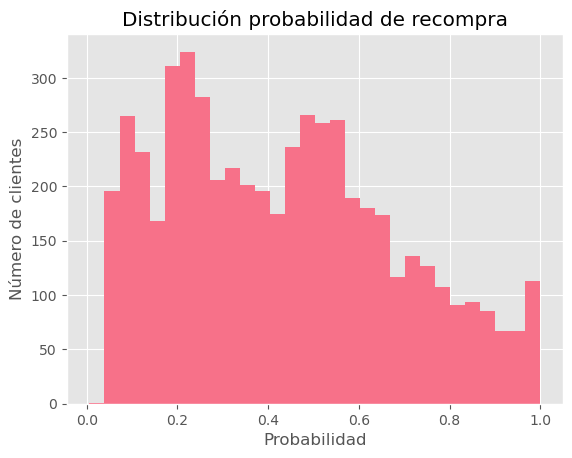

In [44]:
plt.hist(df_model["prob_recompra"], bins=30)
plt.title("Distribución probabilidad de recompra")
plt.xlabel("Probabilidad")
plt.ylabel("Número de clientes")
plt.show()

In [45]:
df_model.sort_values("prob_recompra", ascending=False).head(10)

,frequency,monetary,avg_ticket,total_quantity,n_products,n_returns,recency,return_rate,target,prob_recompra,segment
customer_id,,,,,,,,,,,
14911,400,205290.85,23.801838,111191,2189,263,0,0.657500,1,1.000000,High
14156,183,277710.21,71.007469,155273,1385,71,1,0.387978,1,1.000000,High
12748,279,31727.75,7.604926,20578,1826,58,1,0.207885,1,1.000000,High
17841,232,50240.40,5.383092,26438,1943,153,0,0.659483,1,1.000000,High
14646,132,421438.67,132.361391,298022,807,36,1,0.272727,1,1.000000,High
18102,120,446174.06,570.555064,148994,313,10,7,0.083333,1,1.000000,High
15311,238,97344.85,24.998677,61466,785,241,2,1.012605,1,1.000000,High
14606,229,26652.11,4.567628,13881,1229,132,1,0.576419,1,1.000000,High
13089,219,94424.35,31.686023,51689,778,73,8,0.333333,1,1.000000,High


In [46]:
df_model.sort_values("prob_recompra").head(10)

,frequency,monetary,avg_ticket,total_quantity,n_products,n_returns,recency,return_rate,target,prob_recompra,segment
customer_id,,,,,,,,,,,
17399,1,-25111.09,-25111.090000,0,1,1,448,1.000000,0,0.005986,Low
15849,1,-5876.34,-5876.340000,0,1,1,504,1.000000,0,0.046358,Low
12918,3,-10953.50,-3651.166667,1,1,2,534,0.666667,0,0.047031,Low
17641,1,-6.95,-6.950000,0,1,1,647,1.000000,0,0.048600,Low
15999,1,20.40,20.400000,24,1,0,644,0.000000,0,0.049144,Low
12636,1,141.00,141.000000,1,1,0,647,0.000000,0,0.049183,Low
15833,1,80.40,16.080000,24,5,0,646,0.000000,0,0.049640,Low
12934,1,181.65,90.825000,31,2,0,645,0.000000,0,0.049666,Low
16404,1,-12.75,-12.750000,0,1,1,641,1.000000,1,0.049878,Low


In [48]:
df_model["segment"].value_counts()

segment
Medium    2489
Low       1956
High       897
Name: count, dtype: int64

In [50]:
df_past.shape

(635126, 17)

In [51]:
df_model.shape

(5342, 11)